<a href="https://colab.research.google.com/github/chaitrika0203/Fake-News-Detection-Using-ML/blob/main/Copy_of_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/content/Twitter_Data.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Use the 'python' engine and set `on_bad_lines='skip'`
# to handle potential quoting issues and skip problematic lines
df = pd.read_csv('/content/Twitter_Data.csv', engine='python', on_bad_lines='skip')
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.isnull().sum()

,0
clean_text,4
category,7


In [ ]:
#Dropping the null values
df.dropna(inplace=True)
original_df = df.copy()

In [ ]:
df[df.duplicated()]

,clean_text,category


In [ ]:
#Removal of any Duplicate rows (if any)

counter = 0
r,c = original_df.shape

df_dedup = df.drop_duplicates()
df_dedup.reset_index(drop=True, inplace=True)

if df_dedup.shape==(r,c):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped/fixed ---> {r-df_dedup.shape[0]}')


Inference: The dataset doesn't have any duplicates


In [ ]:
df_dedup.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


Text Processing

In [ ]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
#Filtering the text

df_fltr = df_dedup.copy()

def preprocessor(text):
    #text = re.sub('[http:,https:]','',text)
    text = re.sub('[^a-zA-Z]',' ',text)
    text = text.lower()
    text = text.strip()
    text = ''.join([i for i in text if i in string.ascii_lowercase+' '])
    text = ' '.join([word for word in text.split() if word.isalnum()])
    text = ' '.join([WordNetLemmatizer().lemmatize(word,pos='v') for word in text.split()])
    #text = ' '.join([PorterStemmer().stem(word) for word in text.split()])
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])
    #text = ' '.join([word for word in text.split() if len(word)>3])
    return text

In [ ]:
# Assuming your column is named 'clean_text' based on the global variables provided
df_fltr['clean_text'] = df_dedup['clean_text'].apply(preprocessor) # Change 'text' to 'clean_text'
df_fltr.head()

,clean_text,category
0,modi promise minimum government maximum govern...,-1.0
1,talk nonsense continue drama vote modi,0.0
2,say vote modi welcome bjp tell rahul main camp...,1.0
3,ask supporters prefix chowkidar name modi grea...,1.0
4,answer among powerful world leader today trump...,1.0


In [ ]:
df.shape

(162969, 2)

In [ ]:
df['category'] = df['category'].replace(4,1) # 1 positive sentiment
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


In [ ]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [ ]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Use NLTK's stopwords corpus directly
stopwords_set = set(stopwords.words('english'))
print(stopwords_set)

{'ain', 'can', "wouldn't", "you're", 'up', 'isn', 'do', 'but', 'won', 'few', 'he', 'theirs', 'yourself', 'it', 'which', 'and', 'being', 'those', "doesn't", 'whom', 'nor', 've', "i've", 'have', "they'll", 'in', 'are', 'during', 'shouldn', "that'll", 'your', 'for', "don't", 'most', 'we', "you'll", 'they', 'now', 'should', 'between', "i'd", 'needn', 'me', 'the', 'such', 'haven', 'how', "haven't", 'mustn', 'doesn', 'too', "we'll", 'off', 'its', "shan't", 'so', "we've", 'doing', 'm', 'our', 'that', 'shan', 'these', 'not', "she's", "you've", 'were', 'him', 'no', 'a', 'above', "didn't", 'after', 'below', 'wouldn', 'yourselves', "shouldn't", 'through', 'you', "it's", 'both', 'what', 'their', "he'll", "it'll", 'himself', "he'd", "i'm", 'who', 'itself', 'by', 'here', 'or', "they've", 'because', 'own', 'more', 'his', "wasn't", 'be', "needn't", 'an', 'same', 'from', "couldn't", 'each', 'hasn', 'there', "won't", 'herself', "hadn't", 'with', "he's", 'just', 'all', 'don', 'myself', 'does', 'over', 's

In [ ]:
import re
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Initialize stemmer and lemmatizer
ps = PorterStemmer()
lm = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs before tokenization
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Tokenize the text into words
    words = word_tokenize(text)

    # 5. Remove stopwords
    words = [word for word in words if word not in stopwords_set]

    # 6. Remove punctuation
    words = [word for word in words if word not in string.punctuation]

    # 7. Remove repeating characters (e.g., "soooon" -> "soon")
    words = [re.sub(r'(.)\1+', r'\1', word) for word in words]

    # 8. Apply stemming (e.g., "running" -> "run")
    words = [ps.stem(word) for word in words]
    text = ' '.join(words)
    return text

In [ ]:
df['clean_text'][0]

'when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples'

In [ ]:
import nltk
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
preprocess_text(df['clean_text'][0])

'modi promis “ minimum govern maximum govern ” expect begin dificult job reform state take year get justic state busin exit psu templ'

In [ ]:
df['clean_text'] = df['clean_text'].apply(preprocess_text)

In [ ]:
df['clean_text'][0]

'modi promis “ minimum govern maximum govern ” expect begin dificult job reform state take year get justic state busin exit psu templ'

In [ ]:
df.head()


,clean_text,category
0,modi promis “ minimum govern maximum govern ” ...,-1.0
1,talk nonsens continu drama vote modi,0.0
2,say vote modi welcom bjp told rahul main campa...,1.0
3,ask suport prefix chowkidar name modi great se...,1.0
4,answer among power world leader today trump pu...,1.0


In [ ]:
df_neg = df[df['category']==0]
df_neg

,clean_text,category
1,talk nonsens continu drama vote modi,0.0
5,kiya tho refresh markefir coment karo,0.0
6,surat women perform yagna sek divin grace nare...,0.0
7,come cabinet scholar like modi smriti hema tim...,0.0
13,one vote make difer anil kapor answer modi ele...,0.0
...,...,...
162968,case dont lok candid case person like manmohan...,0.0
162971,congr veteran sudhakar redi join bjp mete modi,0.0
162974,save agenda pedl ’ teror atack everi second da...,0.0
162977,cover interact forum left,0.0


In [ ]:
df_pos = df[df['category']==1]
df_pos

,clean_text,category
2,say vote modi welcom bjp told rahul main campa...,1.0
3,ask suport prefix chowkidar name modi great se...,1.0
4,answer among power world leader today trump pu...,1.0
8,upcom elect india saga go import pair lok cure...,1.0
9,gandhi gay modi,1.0
...,...,...
162969,object cover everyth akhlaq ramalingam questio...,1.0
162970,raga know dat wont spare modi court cheat coru...,1.0
162972,engin growth modi unveil india first electr lo...,1.0
162973,modi promis lok sabha elect best orop given so...,1.0


In [ ]:
df_neu = df[df['category']==-1]
df_neu

,clean_text,category
0,modi promis “ minimum govern maximum govern ” ...,-1.0
15,vote parti leadershipwho take fast firm action...,-1.0
19,’ write chowkidar mean ’ anti modi tri visit p...,-1.0
21,firm belief leadership shri narendra modi bjp ...,-1.0
23,sultanpur utar pradesh loksabha candid select ...,-1.0
...,...,...
162956,narend modi contest two seat member parliament...,-1.0
162962,modi decim congr front crore congr head share ...,-1.0
162967,azamgarh pleas por work requir jogiadhiyanath ...,-1.0
162975,crore paid nerav modi recov congr leader hard ...,-1.0


In [ ]:
from wordcloud import WordCloud

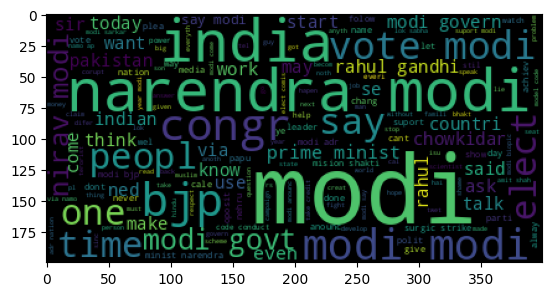

In [ ]:
wc_neg = WordCloud()
wc_neg.generate(' '.join(df_neg['clean_text']))
plt.imshow(wc_neg)

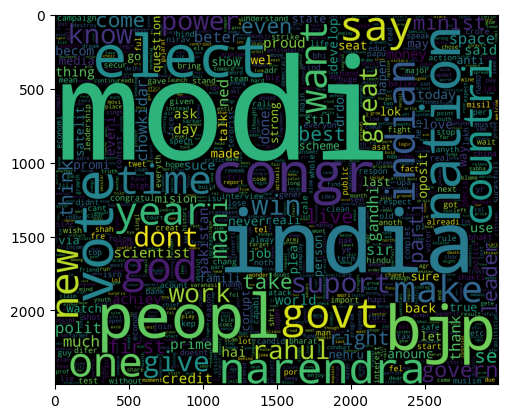

In [ ]:
wc_pos = WordCloud(max_words = 1000 , width = 3000 , height = 2500,
               collocations=False)
wc_pos.generate(' '.join(df_pos['clean_text']))
plt.imshow(wc_pos)

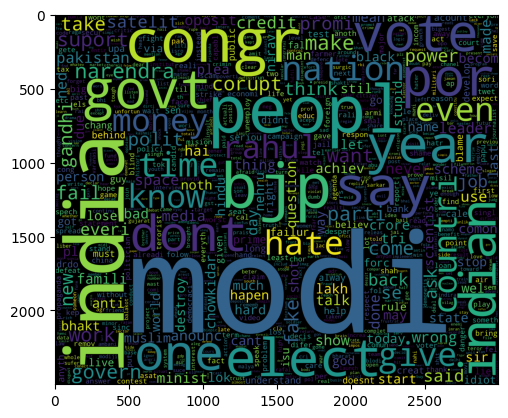

In [ ]:
wc_neu = WordCloud(max_words = 1000 , width = 3000 , height = 2500,
               collocations=False)
wc_neu.generate(' '.join(df_neu['clean_text']))
plt.imshow(wc_neu)

In [ ]:
new_df = pd.concat([df_neg[:15000], df_pos[:15000]])
new_df.shape

(30000, 2)

Model Building

In [ ]:
x = df['clean_text']  # Assign 'clean_text' column to X
y = df['category']    # Assign 'category' column to y

# Now you can split the data

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((130375,), (32594,), (130375,), (32594,))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# 2. Fit the vectorizer to your training data and transform it
x_train_vec = vectorizer.fit_transform(x_train)

# 3. Transform the testing data using the same vectorizer
x_test_vec = vectorizer.transform(x_test)



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Create a TF-IDF vectorizer (you've already done this)
# vectorizer = TfidfVectorizer()

# 2. Fit the vectorizer to your training data and transform it (you've done this too)
# x_train_vec = vectorizer.fit_transform(x_train)

# 3. Transform the testing data using the same vectorizer (and this)
# x_test_vec = vectorizer.transform(x_test)

# 4. Initialize and train the Logistic Regression model
#    using the vectorized training data
LR=LogisticRegression()
LR.fit(x_train_vec,y_train) # Use x_train_vec instead of x_train

# 5. Make predictions on the vectorized test data
# predictions = LR.predict(x_test_vec)  # Use x_test_vec for predictions

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
LR.score(x_test_vec,y_test)

0.839755783272995

In [ ]:
pred_lr = LR.predict(x_test_vec)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

        -1.0       0.82      0.72      0.76      7152
         0.0       0.82      0.90      0.86     11067
         1.0       0.87      0.85      0.86     14375

    accuracy                           0.84     32594
   macro avg       0.83      0.82      0.83     32594
weighted avg       0.84      0.84      0.84     32594



Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(x_train_vec, y_train)

DecisionTreeClassifier()

In [ ]:
pred_dt = DT.predict(x_test_vec)

In [ ]:
DT.score(x_test_vec,y_test)

0.7763085230410505

In [ ]:
print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

        -1.0       0.68      0.64      0.66      7152
         0.0       0.81      0.83      0.82     11067
         1.0       0.80      0.80      0.80     14375

    accuracy                           0.78     32594
   macro avg       0.76      0.76      0.76     32594
weighted avg       0.77      0.78      0.78     32594



Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GB = GradientBoostingClassifier(random_state=0)
GB.fit(x_train_vec,y_train)

GradientBoostingClassifier(random_state=0)

In [ ]:
pred_gb = GB.predict(x_test_vec)

In [ ]:
GB.score(x_test_vec,y_test)

0.7073694545008283

In [ ]:
print(classification_report(y_test,pred_gb))

              precision    recall  f1-score   support

        -1.0       0.82      0.39      0.53      7152
         0.0       0.66      0.81      0.73     11067
         1.0       0.72      0.79      0.75     14375

    accuracy                           0.71     32594
   macro avg       0.74      0.66      0.67     32594
weighted avg       0.72      0.71      0.70     32594



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state=0)
RF.fit(x_train_vec,y_train)

RandomForestClassifier(random_state=0)

In [ ]:
pred_rf = RF.predict(x_test_vec)

In [ ]:
RF.score(x_test_vec,y_test)

0.8041357305025465

In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

        -1.0       0.86      0.55      0.67      7152
         0.0       0.81      0.87      0.84     11067
         1.0       0.78      0.88      0.83     14375

    accuracy                           0.80     32594
   macro avg       0.82      0.77      0.78     32594
weighted avg       0.81      0.80      0.80     32594



comparing


In [ ]:
# Define a dictionary to store your results
results_dict = {
    "Model": ["LR", "DT", "GB", "RF"],
    "Score": [
        LR.score(x_test_vec, y_test),
        DT.score(x_test_vec, y_test),
        GB.score(x_test_vec, y_test),
        RF.score(x_test_vec, y_test)
    ]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results_dict)
results_df

,Model,Score
0,LR,0.839756
1,DT,0.776309
2,GB,0.707369
3,RF,0.804136


In [ ]:
train_labels = [round(score, 2) for score in results_df['Score']]  # Use 'Score' column
test_labels = train_labels  # Assuming you want test labels to be the same since there's no separate test accuracy column

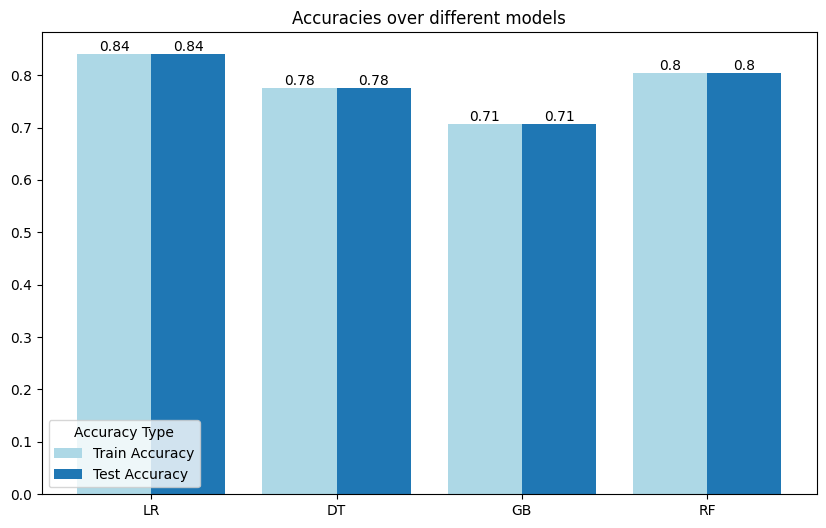

In [ ]:
w_bar=0.4
plt.figure(figsize=(10,6))
plt.title('Accuracies over different models')
bar1 = np.arange(len(results_df['Model']))
bar2 = [i+w_bar for i in bar1]
bars_train = plt.bar(data=results_df, x=bar1, height='Score', width=w_bar, color='lightblue') # Change 'height' to use 'Score'
bars_test = plt.bar(data=results_df, x=bar2, height='Score', width=w_bar)  # Change 'height' to use 'Score'
plt.bar_label(bars_train, labels=train_labels)
plt.bar_label(bars_test, labels=test_labels)
models_names = results_df['Model'].tolist()  # Define models_names using the 'Model' column
plt.xticks(bar1+w_bar/2,models_names)
plt.legend(handles=[bars_train, bars_test], title='Accuracy Type', labels=['Train Accuracy', 'Test Accuracy'])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# ... (your previous code for model training and predictions) ...

# Define a dictionary to store your results
results_dict = {
    "Model": ["LR", "DT", "GB", "RF"],
    "Score": [
        accuracy_score(y_test, pred_lr),  # LR
        accuracy_score(y_test, pred_dt),  # DT
        accuracy_score(y_test, pred_gb),  # GB
        accuracy_score(y_test, pred_rf)   # RF
    ],
    "F1 Score - Class 0": [
        f1_score(y_test, pred_lr, average=None)[0],  # LR
        f1_score(y_test, pred_dt, average=None)[0],  # DT
        f1_score(y_test, pred_gb, average=None)[0],  # GB
        f1_score(y_test, pred_rf, average=None)[0]   # RF
    ],
    "F1 Score - Class 1": [
        f1_score(y_test, pred_lr, average=None)[1],  # LR
        f1_score(y_test, pred_dt, average=None)[1],  # DT
        f1_score(y_test, pred_gb, average=None)[1],  # GB
        f1_score(y_test, pred_rf, average=None)[1]   # RF
    ],
    "Precision - Class 0": [
        precision_score(y_test, pred_lr, average=None)[0],  # LR
        precision_score(y_test, pred_dt, average=None)[0],  # DT
        precision_score(y_test, pred_gb, average=None)[0],  # GB
        precision_score(y_test, pred_rf, average=None)[0]   # RF
    ],
    "Precision - Class 1": [
        precision_score(y_test, pred_lr, average=None)[1],  # LR
        precision_score(y_test, pred_dt, average=None)[1],  # DT
        precision_score(y_test, pred_gb, average=None)[1],  # GB
        precision_score(y_test, pred_rf, average=None)[1]   # RF
    ],
    "Recall - Class 0": [
        recall_score(y_test, pred_lr, average=None)[0],  # LR
        recall_score(y_test, pred_dt, average=None)[0],  # DT
        recall_score(y_test, pred_gb, average=None)[0],  # GB
        recall_score(y_test, pred_rf, average=None)[0]   # RF
    ],
    "Recall - Class 1": [
        recall_score(y_test, pred_lr, average=None)[1],  # LR
        recall_score(y_test, pred_dt, average=None)[1],  # DT
        recall_score(y_test, pred_gb, average=None)[1],  # GB
        recall_score(y_test, pred_rf, average=None)[1]   # RF
    ]
}


In [ ]:
# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results_dict)

In [ ]:
# Define labels for bar plots (moved here for proper scope)
f1_score_0_labels = [round(score, 2) for score in results_df['F1 Score - Class 0']]
f1_score_1_labels = [round(score, 2) for score in results_df['F1 Score - Class 1']]
# ... (other labels for precision and recall) ...
models_names = results_df['Model'].tolist()  # Define models_names here


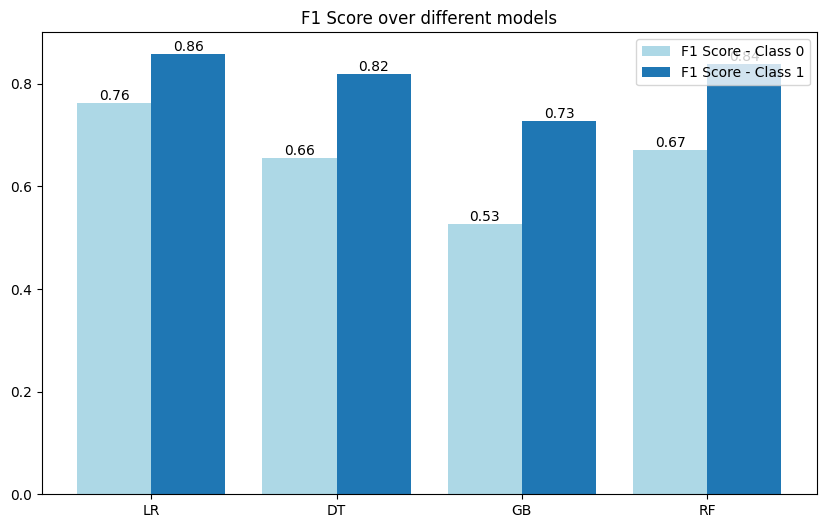

In [ ]:
# Now you can create your bar plots using these labels

w_bar = 0.4
plt.figure(figsize=(10, 6))
plt.title('F1 Score over different models')
bar1 = np.arange(len(results_df['Model']))
bar2 = [i + w_bar for i in bar1]
bars_0 = plt.bar(data=results_df, x=bar1, height='F1 Score - Class 0', width=w_bar, color='lightblue')
bars_1 = plt.bar(data=results_df, x=bar2, height='F1 Score - Class 1', width=w_bar)
plt.bar_label(bars_0, labels=f1_score_0_labels)
plt.bar_label(bars_1, labels=f1_score_1_labels)
plt.xticks(bar1 + w_bar / 2, models_names)
plt.legend(handles=[bars_0, bars_1], labels=['F1 Score - Class 0', 'F1 Score - Class 1'])
plt.show()

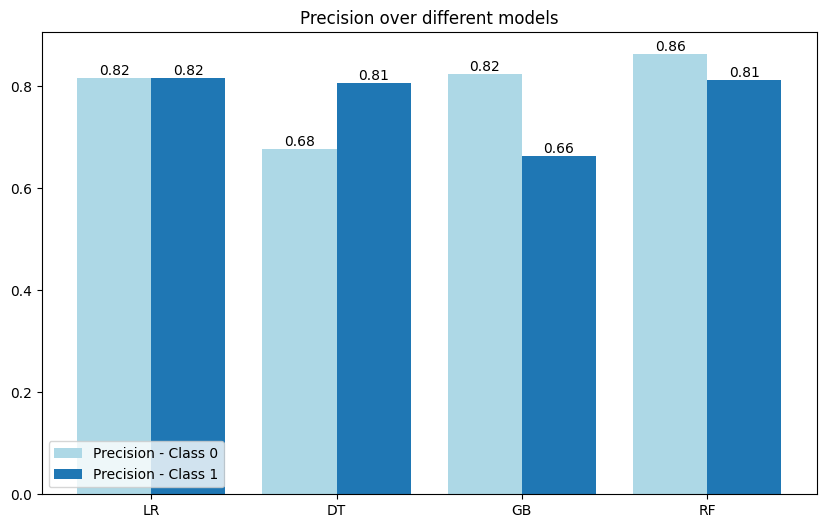

In [ ]:
w_bar=0.4
plt.figure(figsize=(10,6))
plt.title('Precision over different models')
bar1 = np.arange(len(results_df['Model']))
bar2 = [i+w_bar for i in bar1]
bars_0 = plt.bar(data=results_df, x=bar1, height='Precision - Class 0', width=w_bar, color='lightblue')
bars_1 = plt.bar(data=results_df, x=bar2, height='Precision - Class 1', width=w_bar)

# Define precision labels before using them
precision_0_labels = [round(score, 2) for score in results_df['Precision - Class 0']]
precision_1_labels = [round(score, 2) for score in results_df['Precision - Class 1']]

plt.bar_label(bars_0, labels=precision_0_labels)
plt.bar_label(bars_1, labels=precision_1_labels)
plt.xticks(bar1+w_bar/2,models_names)
plt.legend(handles=[bars_0, bars_1], labels=['Precision - Class 0', 'Precision - Class 1'])
plt.show()

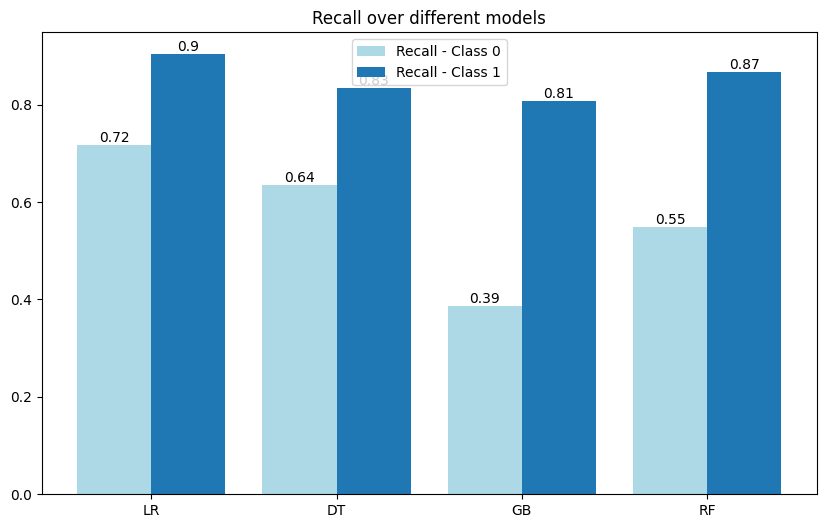

In [ ]:
w_bar=0.4
plt.figure(figsize=(10,6))
plt.title('Recall over different models')
bar1 = np.arange(len(results_df['Model']))
bar2 = [i+w_bar for i in bar1]
bars_0 = plt.bar(data=results_df, x=bar1, height='Recall - Class 0', width=w_bar, color='lightblue')
bars_1 = plt.bar(data=results_df, x=bar2, height='Recall - Class 1', width=w_bar)

# Define recall_0_labels and recall_1_labels here, before using them:
recall_0_labels = [round(score, 2) for score in results_df['Recall - Class 0']]
recall_1_labels = [round(score, 2) for score in results_df['Recall - Class 1']]

plt.bar_label(bars_0, labels=recall_0_labels)
plt.bar_label(bars_1, labels=recall_1_labels)
plt.xticks(bar1+w_bar/2,models_names)
plt.legend(handles=[bars_0, bars_1], labels=['Recall - Class 0', 'Recall - Class 1'])
plt.show()

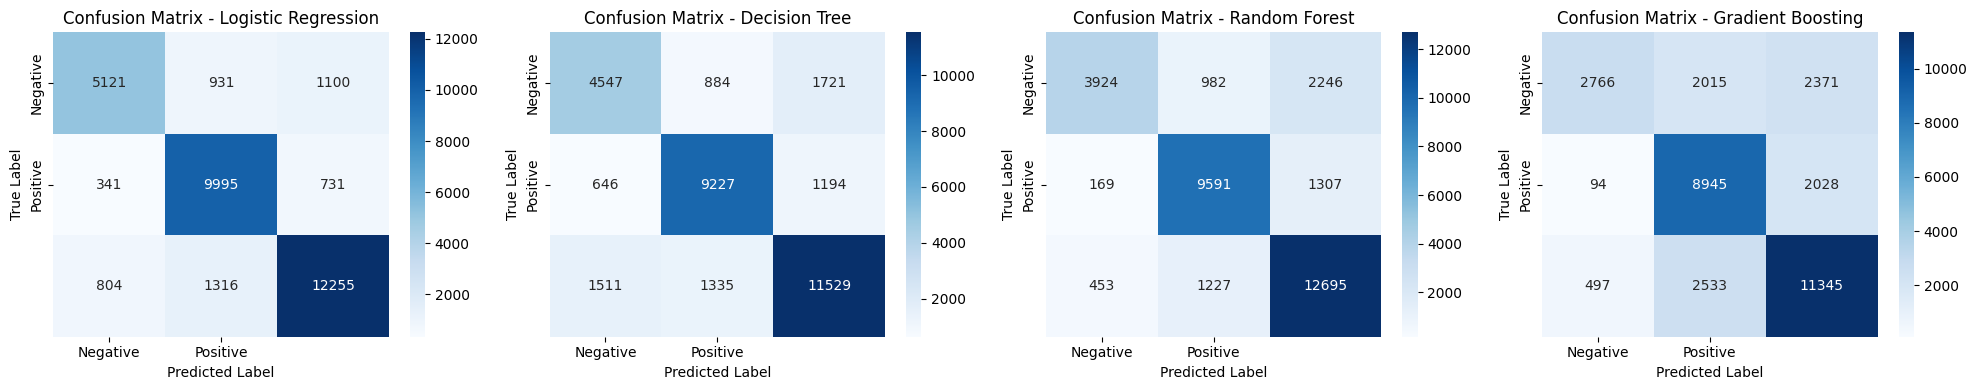

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(models, model_names, X_test, y_test):
    """
    Plots confusion matrices for multiple models.

    Args:
        models: A list of trained scikit-learn models.
        model_names: A list of corresponding model names (strings).
        X_test: The test data (features).
        y_test: The test data (labels).
    """
    num_models = len(models)
    fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 4))  # Adjust figsize as needed

    for i, (model, model_name) in enumerate(zip(models, model_names)):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Plot confusion matrix using seaborn
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                    xticklabels=['Negative', 'Positive'],  # Replace with your class labels
                    yticklabels=['Negative', 'Positive'])  # Replace with your class labels

        axes[i].set_title(f"Confusion Matrix - {model_name}")
        axes[i].set_xlabel("Predicted Label")
        axes[i].set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

# Assuming you have your models and data as follows:
# lr_model, DT_model, RF_model, GB_model
# x_test_vec (your vectorized test data)
# y_test

# Call the function to plot the confusion matrices
plot_confusion_matrices([lr_model, DT_model, RF_model, GB_model],
                         ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
                         x_test_vec, y_test)

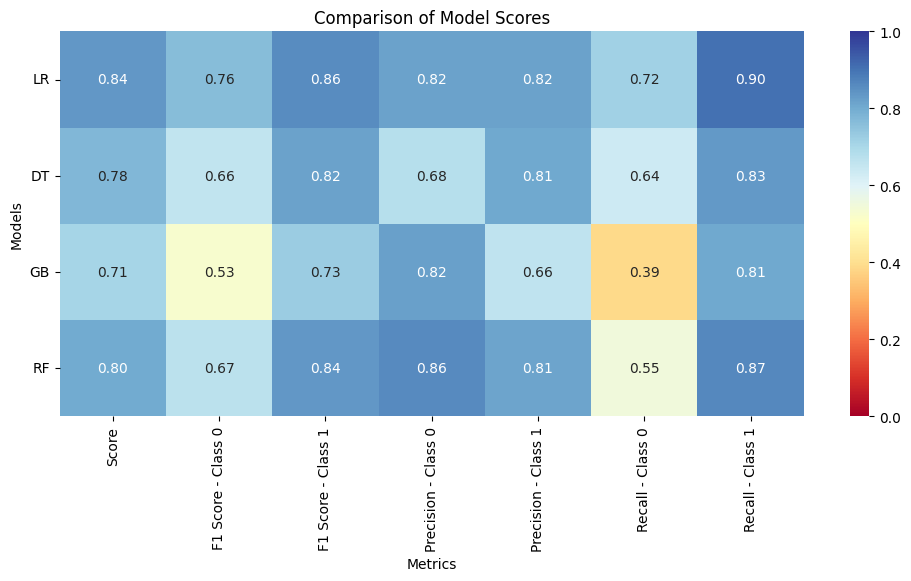

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have your results stored in 'results_df' DataFrame
# (created in the previous code examples)

# Select only the numeric columns for the heatmap
numeric_results_df = results_df.select_dtypes(include=['number'])

# Create a heatmap to compare scores
plt.figure(figsize=[12, 5])
sns.heatmap(numeric_results_df, annot=True, vmin=0, vmax=1, cmap='RdYlBu', fmt='.2f')
# Adjust vmin, vmax, and fmt as needed

# Customize the plot
plt.title('Comparison of Model Scores')
plt.xlabel('Metrics')
plt.ylabel('Models')

# Set y-tick labels to the original model names
plt.yticks(np.arange(len(results_df)) + 0.5, results_df['Model'], rotation=0)

plt.show()

In [ ]:
# prompt: write a code for model testing and manual entry as seperate code by comparing all the models

# Assuming your models (LR, DT, GB, RF) and vectorizer are already trained and available

def predict_sentiment_all_models(tweet, models, vectorizer):
    """Predicts sentiment using all models.

    Args:
        tweet: The input tweet (string).
        models: A dictionary of trained models.
        vectorizer: The trained TF-IDF vectorizer.

    Returns:
        A dictionary of predictions from each model.
    """
    processed_tweet = preprocess_text(tweet)  # Assuming preprocess_text is defined
    tweet_vec = vectorizer.transform([processed_tweet])

    predictions = {}
    for model_name, model in models.items():
        prediction = model.predict(tweet_vec)[0]
        predictions[model_name] = prediction

    return predictions

# Example usage (assuming models, vectorizer are defined):
models = {
    'LR': LR,
    'DT': DT,
    'GB': GB,
    'RF': RF
}

In [ ]:
# Model Testing
# ... (Your existing model testing code using x_test_vec and y_test) ...


# Manual Entry
user_tweet = input("Enter a tweet: ")
all_predictions = predict_sentiment_all_models(user_tweet, models, vectorizer)

print("Predictions:")
for model_name, prediction in all_predictions.items():
    sentiment_label = "Positive" if prediction == 1 else "Negative" if prediction == 0 else "Neutral"
    print(f"{model_name}: {sentiment_label}")

Enter a tweet: will give modi whistle and cap wants chowkidar akbaruddinÂ owaisi 
Predictions:
LR: Negative
DT: Negative
GB: Negative
RF: Negative


In [ ]:
user_tweet = input("Enter a tweet: ")
all_predictions = predict_sentiment_all_models(user_tweet, models, vectorizer)

print("Predictions:")
for model_name, prediction in all_predictions.items():
    sentiment_label = "Positive" if prediction == 1 else "Negative" if prediction == 0 else "Neutral"
    print(f"{model_name}: {sentiment_label}")

Enter a tweet: stop comparing bigot mass murderer modi with someone like imran khan
Predictions:
LR: Negative
DT: Negative
GB: Negative
RF: Negative


In [ ]:
user_tweet = input("Enter a tweet: ")
all_predictions = predict_sentiment_all_models(user_tweet, models, vectorizer)

print("Predictions:")
for model_name, prediction in all_predictions.items():
    sentiment_label = "Positive" if prediction == 1 else "Negative" if prediction == 0 else "Neutral"
    print(f"{model_name}: {sentiment_label}")

Enter a tweet: why vote modi dynasty visionary 3no high level corruption 4solid team changing base though will take time more time will give result congress will loot knowing well chance again internalexternal security 910 nationalism
Predictions:
LR: Positive
DT: Positive
GB: Positive
RF: Positive


In [ ]:
user_tweet = input("Enter a tweet: ")
all_predictions = predict_sentiment_all_models(user_tweet, models, vectorizer)

print("Predictions:")
for model_name, prediction in all_predictions.items():
    sentiment_label = "Positive" if prediction == 1 else "Negative" if prediction == 0 else "Neutral"
    print(f"{model_name}: {sentiment_label}")

Enter a tweet: social media lampoons modiâ€™ evolution from chowkidar salesman the prime minister india with â€˜chowkidarâ€™ his name was caught peddling tshirts keychains twitter read 
Predictions:
LR: Positive
DT: Positive
GB: Positive
RF: Positive


In [ ]:
user_tweet = input("Enter a tweet: ")
all_predictions = predict_sentiment_all_models(user_tweet, models, vectorizer)

print("Predictions:")
for model_name, prediction in all_predictions.items():
    sentiment_label = "Positive" if prediction == 1 else "Negative" if prediction == 0 else "Neutral"
    print(f"{model_name}: {sentiment_label}")

Enter a tweet: momota begum will let her state become total shithole than let anyone else bring development and hog limelight and dont just mean modi
Predictions:
LR: Negative
DT: Positive
GB: Positive
RF: Neutral
